### 한국어 데이터로 챗봇 만들기

In [1]:
!pip install sentencepiece -q

In [2]:
# 라이브러리 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm
import math
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
 
print("torch 버전:", torch.__version__)
print("sentencepiece 버전:", spm.__version__)

torch 버전: 2.7.1+cu118
sentencepiece 버전: 0.2.1


In [3]:
!wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv

--2026-04-20 05:27:07--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-04-20 05:27:07--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv.11’

ChatbotData.csv.11  100%[===================>] 868.99K  --.-KB/s    in 0.1s    

2026-04-20 05:27:08 (5.72 MB/s) - ‘ChatbotData.csv.11’ saved [889842/889842]



1. 데이터 수집

In [4]:
DATA_PATH = "ChatbotData.csv"
 
df = pd.read_csv(DATA_PATH)
print("전체 샘플 수:", len(df))
print(df.head(5))
 
pairs = list(zip(df["Q"], df["A"]))
print("\n첫 번째 쌍:", pairs[0])

전체 샘플 수: 11823
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0

첫 번째 쌍: ('12시 땡!', '하루가 또 가네요.')


2. 데이터 전처리 함수 정의

In [5]:
def preprocess_sentence(sentence):
    """
    한국어 전처리 함수
 
    영어와 다른 점:
      - 소문자 변환 불필요 (한국어는 대소문자 없음)
      - 한글(가-힣) + 영문 + 숫자 + 기본 구두점만 유지
      - 나머지 특수문자·이모지 등은 공백으로 제거
 
    처리 순서:
      1) 양쪽 공백 제거
      2) 구두점 앞뒤에 공백 삽입 (토크나이저 분리 보조)
      3) 연속 공백 → 단일 공백
      4) 한글·영문·숫자·구두점 외 제거
      5) 최종 공백 제거
    """
    sentence = str(sentence).strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence) # 구두점 앞뒤 공백
    sentence = re.sub(r"[ ]+", " ", sentence)         # 연속 공백 제거
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence) # 특수문자 제거
    sentence = sentence.strip()
    return sentence
 
 
cleaned_pairs = []
for q, a in pairs:
    q_clean = preprocess_sentence(q)
    a_clean = preprocess_sentence(a)
    if q_clean and a_clean:
        cleaned_pairs.append((q_clean, a_clean))
 
print("전처리 후 샘플 수:", len(cleaned_pairs))


전처리 후 샘플 수: 11823


3. 데이터 전처리 분석

In [6]:
samples = [
    "오늘 기분이 너무 안 좋아😢",
    "취업준비중인데 너무힘들어요!!",
    "1지망 학교 떨어졌어ㅠㅠ",
]
print("=== 전처리 전후 비교 ===")
for s in samples:
    print(f"  원본    : {s}")
    print(f"  전처리후: {preprocess_sentence(s)}")
    print()


=== 전처리 전후 비교 ===
  원본    : 오늘 기분이 너무 안 좋아😢
  전처리후: 오늘 기분이 너무 안 좋아

  원본    : 취업준비중인데 너무힘들어요!!
  전처리후: 취업준비중인데 너무힘들어요 ! !

  원본    : 1지망 학교 떨어졌어ㅠㅠ
  전처리후: 1지망 학교 떨어졌어



4. SentencePiece 토크나이저 학습

In [7]:
CORPUS_FILE = "ko_corpus.txt"
SPM_PREFIX  = "spm_korean"
VOCAB_SIZE  = 8000
 
with open(CORPUS_FILE, "w", encoding="utf-8") as f:
    for q, a in cleaned_pairs:
        f.write(q + "\n")
        f.write(a + "\n")
 
spm.SentencePieceTrainer.Train(
    input=CORPUS_FILE,
    model_prefix=SPM_PREFIX,
    vocab_size=VOCAB_SIZE,
    character_coverage=1.0,   # 한국어 전체 문자 커버
    model_type="bpe",         # 서브워드 토크나이징
    max_sentence_length=999999,
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3,
)
print("SentencePiece 학습 완료!")

SentencePiece 학습 완료!


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ko_corpus.txt
  input_format: 
  model_prefix: spm_korean
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differenti

5. 토크나이저 로드 및 분석

In [8]:
sp = spm.SentencePieceProcessor()
sp.Load(f"{SPM_PREFIX}.model")
print("어휘 사전 크기:", sp.GetPieceSize())
 
print("\n=== 토크나이징 결과 분석 ===")
test_sents = [
    "오늘 날씨가 너무 좋아",
    "취업 준비가 너무 힘들어",
    "사랑하는 사람이 생겼어",
]
for s in test_sents:
    tokens  = sp.encode(s, out_type=str)
    ids     = sp.encode(s, out_type=int)
    decoded = sp.decode(ids)
    print(f"  문장    : {s}")
    print(f"  서브워드: {tokens}")
    print(f"  토큰 수 : {len(tokens)}")
    print(f"  디코딩  : {decoded}")
    print()

어휘 사전 크기: 8000

=== 토크나이징 결과 분석 ===
  문장    : 오늘 날씨가 너무 좋아
  서브워드: ['▁오늘', '▁날씨가', '▁너무', '▁좋아']
  토큰 수 : 4
  디코딩  : 오늘 날씨가 너무 좋아

  문장    : 취업 준비가 너무 힘들어
  서브워드: ['▁취업', '▁준비가', '▁너무', '▁힘들어']
  토큰 수 : 4
  디코딩  : 취업 준비가 너무 힘들어

  문장    : 사랑하는 사람이 생겼어
  서브워드: ['▁사랑하는', '▁사람이', '▁생겼어']
  토큰 수 : 3
  디코딩  : 사랑하는 사람이 생겼어



6. 병렬 데이터셋 구성

In [9]:
MAX_LENGTH = 40
 
class KoreanChatbotDataset(Dataset):
    """
    한국어 챗봇 병렬 데이터셋
 
    Teacher Forcing 방식:
        enc_input : [BOS] + 질문 토큰 + [EOS] + 패딩
        dec_input : [BOS] + 답변 토큰
        target    :        답변 토큰 + [EOS]
    """
    def __init__(self, pairs, sp, max_length=40):
        super().__init__()
        self.data = []
        bos_id = sp.bos_id()
        eos_id = sp.eos_id()
        pad_id = 0
 
        for q_text, a_text in pairs:
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)
 
            q_tokens = [bos_id] + q_ids + [eos_id]
            a_tokens = [bos_id] + a_ids + [eos_id]
 
            if len(q_tokens) > max_length or len(a_tokens) > max_length:
                continue
 
            q_tokens += [pad_id] * (max_length - len(q_tokens))
            a_tokens += [pad_id] * (max_length - len(a_tokens))
 
            dec_input = a_tokens[:-1]
            target    = a_tokens[1:]
 
            self.data.append({
                "enc_input": q_tokens,
                "dec_input": dec_input,
                "target":    target,
            })
 
    def __len__(self):
        return len(self.data)
 
    def __getitem__(self, idx):
        s = self.data[idx]
        return (
            torch.tensor(s["enc_input"], dtype=torch.long),
            torch.tensor(s["dec_input"], dtype=torch.long),
            torch.tensor(s["target"],    dtype=torch.long),
        )
 
 
dataset    = KoreanChatbotDataset(cleaned_pairs, sp, max_length=MAX_LENGTH)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

7. 병렬 데이터 구축 통계 분석

In [10]:
# 병렬 데이터 구축 통계 분석
q_lens = [len(sp.encode(q)) for q, a in cleaned_pairs]
a_lens = [len(sp.encode(a)) for q, a in cleaned_pairs]
 
print("=== 병렬 데이터 구축 통계 ===")
print(f"  원본 쌍        : {len(pairs):,} 개")
print(f"  전처리 후      : {len(cleaned_pairs):,} 개")
print(f"  유효 샘플 수   : {len(dataset):,} 개")
print(f"  필터링 유지율  : {len(dataset)/len(pairs)*100:.1f}%")
print(f"  질문 평균 토큰 : {sum(q_lens)/len(q_lens):.1f}")
print(f"  답변 평균 토큰 : {sum(a_lens)/len(a_lens):.1f}")
 
for enc, dec, tgt in dataloader:
    print(f"\n  enc_input shape : {enc.shape}")
    print(f"  dec_input shape : {dec.shape}")
    print(f"  target    shape : {tgt.shape}")
    break


=== 병렬 데이터 구축 통계 ===
  원본 쌍        : 11,823 개
  전처리 후      : 11,823 개
  유효 샘플 수   : 11,823 개
  필터링 유지율  : 100.0%
  질문 평균 토큰 : 5.4
  답변 평균 토큰 : 5.8

  enc_input shape : torch.Size([64, 40])
  dec_input shape : torch.Size([64, 39])
  target    shape : torch.Size([64, 39])


8. 트랜스포머 모델 클래스 정의

In [11]:
# 포지셔널 인코딩
class PositionalEncoding(nn.Module):

    def __init__(self, position, d_model):
        super().__init__()
        self.pos_encoding = self._build(position, d_model)
 
    def _build(self, position, d_model):
        pos    = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i      = torch.arange(d_model,  dtype=torch.float32).unsqueeze(0)
        angles = 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * pos
        pe     = torch.zeros(position, d_model)
        pe[:, 0::2] = torch.sin(angles[:, 0::2])
        pe[:, 1::2] = torch.cos(angles[:, 1::2])
        return pe.unsqueeze(0)
 
    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)
 
# scaled dot product attention 
def scaled_dot_product_attention(query, key, value, mask=None):
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))
    logits    = matmul_qk / math.sqrt(key.size(-1))
    if mask is not None:
        logits = logits + (mask * -1e9)
    weights = F.softmax(logits, dim=-1)
    return torch.matmul(weights, value), weights
 
# multi head Attention 
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads   = num_heads
        self.d_model     = d_model
        self.depth       = d_model // num_heads
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense   = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)
        self.out_dense   = nn.Linear(d_model, d_model)
 
    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)
 
    def forward(self, query, key, value, mask=None):
        b = query.size(0)
        q = self.split_heads(self.query_dense(query), b)
        k = self.split_heads(self.key_dense(key),     b)
        v = self.split_heads(self.value_dense(value), b)
        attn, _ = scaled_dot_product_attention(q, k, v, mask)
        attn = attn.permute(0, 2, 1, 3).contiguous().view(b, -1, self.d_model)
        return self.out_dense(attn)
 
# padding mask 
def create_padding_mask(x):
    """패딩(0) 위치에 1 → (batch, 1, 1, seq_len)"""
    return (x == 0).float().unsqueeze(1).unsqueeze(2)
# look ahead mask 
def create_look_ahead_mask(x):
    """미래 토큰 차단 + 패딩 마스크 결합 → (batch, 1, seq, seq)"""
    seq_len    = x.size(1)
    look_ahead = (1 - torch.tril(torch.ones(seq_len, seq_len))).unsqueeze(0).unsqueeze(1).to(x.device)
    padding    = create_padding_mask(x)
    return torch.max(look_ahead, padding)
 
# Encoder layer 
class EncoderLayer(nn.Module):
    """멀티-헤드 셀프 어텐션 + FFN + 잔차 연결 + LayerNorm"""
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.mha      = MultiHeadAttention(d_model, num_heads)
        self.dropout1 = nn.Dropout(dropout)
        self.norm1    = nn.LayerNorm(d_model, eps=1e-6)
        self.ffn      = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.ReLU(), nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2    = nn.LayerNorm(d_model, eps=1e-6)
 
    def forward(self, x, mask=None):
        out1 = self.norm1(x    + self.dropout1(self.mha(x, x, x, mask)))
        out2 = self.norm2(out1 + self.dropout2(self.ffn(out1)))
        return out2

# Encoder
class Encoder(nn.Module):
    """임베딩 → 포지셔널 인코딩 → N개 EncoderLayer"""
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.d_model      = d_model
        self.embedding    = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(vocab_size, d_model)
        self.dropout      = nn.Dropout(dropout)
        self.enc_layers   = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)
        ])
 
    def forward(self, x, mask=None):
        x = self.dropout(self.pos_encoding(self.embedding(x) * math.sqrt(self.d_model)))
        for layer in self.enc_layers:
            x = layer(x, mask)
        return x
 
# Decoder Layer 
class DecoderLayer(nn.Module):
    """셀프 어텐션 + 크로스 어텐션 + FFN + 잔차 연결 + LayerNorm"""
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.self_mha   = MultiHeadAttention(d_model, num_heads)
        self.norm1      = nn.LayerNorm(d_model, eps=1e-6)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2      = nn.LayerNorm(d_model, eps=1e-6)
        self.ffn        = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.ReLU(), nn.Linear(ff_dim, d_model)
        )
        self.norm3      = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout1   = nn.Dropout(dropout)
        self.dropout2   = nn.Dropout(dropout)
        self.dropout3   = nn.Dropout(dropout)
 
    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        out1 = self.norm1(x    + self.dropout1(self.self_mha(x, x, x, look_ahead_mask)))
        out2 = self.norm2(out1 + self.dropout2(self.encdec_mha(out1, enc_outputs, enc_outputs, padding_mask)))
        out3 = self.norm3(out2 + self.dropout3(self.ffn(out2)))
        return out3

# Decoder 
class Decoder(nn.Module):
    """임베딩 → 포지셔널 인코딩 → N개 DecoderLayer"""
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.d_model      = d_model
        self.embedding    = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(vocab_size, d_model)
        self.dropout      = nn.Dropout(dropout)
        self.dec_layers   = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)
        ])
 
    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        x = self.dropout(self.pos_encoding(self.embedding(x) * math.sqrt(self.d_model)))
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)
        return x
 
# Transformer 
class Transformer(nn.Module):
    """인코더 + 디코더 + 최종 선형 레이어"""
    def __init__(self, vocab_size, num_layers, units, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.encoder      = Encoder(vocab_size, num_layers, units, d_model, num_heads, dropout)
        self.decoder      = Decoder(vocab_size, num_layers, units, d_model, num_heads, dropout)
        self.final_linear = nn.Linear(d_model, vocab_size)
 
    def forward(self, inputs, dec_inputs):
        enc_mask   = create_padding_mask(inputs)
        look_ahead = create_look_ahead_mask(dec_inputs)
        dec_mask   = create_padding_mask(inputs)
        enc_out    = self.encoder(inputs, mask=enc_mask)
        dec_out    = self.decoder(dec_inputs, enc_out, look_ahead, dec_mask)
        return self.final_linear(dec_out)
 
 
print("모델 클래스 정의 완료!")

모델 클래스 정의 완료!


9. 학습 함수 정의

In [12]:
# 패딩 토큰을 제외한 예측 정확도
def accuracy_function(y_pred, y_true, pad_id=0):
    preds   = y_pred.argmax(dim=-1)
    mask    = (y_true != pad_id)
    correct = (preds == y_true) & mask
    return correct.float().sum() / mask.float().sum()
 
# 단일 배치 학습 : forward → loss → backward → step
def train_step(model, batch, optimizer, loss_fn, device):
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]
    optimizer.zero_grad()
    logits = model(enc_input, dec_input)
    loss   = loss_fn(logits.permute(0, 2, 1), target)
    loss.backward()
    optimizer.step()
    return loss.item(), accuracy_function(logits, target, pad_id=0)
 
# Transformer 논문 LR Schedule : Warmup -> 역제곱근 감소 
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda
 
# 전체 학습 루프
def train(model, dataloader, optimizer, loss_fn, scheduler, num_epochs, device,
          patience=10, min_delta=0.01):
    """
     Early Stopping + Loss/Accuracy 기록
 
    Early Stopping 기준:
        patience  : 연속 미개선 허용 에폭 수
        min_delta : 개선으로 인정할 최소 Loss 감소량
    """
    model.to(device)
    epoch_losses, epoch_accs = [], []
    best_loss        = float("inf")
    patience_cnt     = 0
    best_model_state = None
 
    for epoch in range(num_epochs):
        total_loss, total_acc = 0.0, 0.0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_fn, device)
            total_loss += loss
            total_acc  += acc
            if step % 100 == 0:
                print(f"  [Epoch {epoch+1:02d}, Step {step:4d}] Loss: {loss:.4f}, Acc: {acc:.4f}")
            scheduler.step()
 
        avg_loss = total_loss / len(dataloader)
        avg_acc  = float(total_acc / len(dataloader))
        epoch_losses.append(avg_loss)
        epoch_accs.append(avg_acc)
        print(f" Epoch {epoch+1:02d} 완료 — Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")
 
        if avg_loss < best_loss - min_delta:
            best_loss        = avg_loss
            patience_cnt     = 0
            best_model_state = model.state_dict()
            print(f"  → Loss 개선! best_loss: {best_loss:.4f} (patience 초기화)\n")
        else:
            patience_cnt += 1
            print(f"  → Loss 개선 없음. ({patience_cnt}/{patience})\n")
            if patience_cnt >= patience:
                print(f" Early Stopping 작동, 최적 가중치로 복원합니다.\n")
                model.load_state_dict(best_model_state)
                break
 
    if best_model_state is not None and patience_cnt < patience:
        model.load_state_dict(best_model_state)
 
    return epoch_losses, epoch_accs
 
 
print("학습 함수 정의 완료!")

학습 함수 정의 완료!


10. 모델 생성 및 학습 실행

In [13]:
"""
# 하이퍼파라미터 설정
NUM_LAYERS   = 2
D_MODEL      = 256
NUM_HEADS    = 8
UNITS        = 512
DROPOUT      = 0.1
NUM_EPOCHS   = 50
WARMUP_STEPS = 4000
PATIENCE     = 10
MIN_DELTA    = 0.01
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)
 
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
).to(device)
print(model)
 
loss_fn   = nn.CrossEntropyLoss(ignore_index=sp.pad_id())
optimizer = optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9)
scheduler = lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=WARMUP_STEPS)
)
 
print(f"학습 시작 — 최대 {NUM_EPOCHS} 에폭, patience={PATIENCE}, min_delta={MIN_DELTA}")
epoch_losses, epoch_accs = train(
    model, dataloader, optimizer, loss_fn, scheduler, NUM_EPOCHS, device,
    patience=PATIENCE, min_delta=MIN_DELTA
)
"""

'\n# 하이퍼파라미터 설정\nNUM_LAYERS   = 2\nD_MODEL      = 256\nNUM_HEADS    = 8\nUNITS        = 512\nDROPOUT      = 0.1\nNUM_EPOCHS   = 50\nWARMUP_STEPS = 4000\nPATIENCE     = 10\nMIN_DELTA    = 0.01\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\nprint("사용 디바이스:", device)\n\nmodel = Transformer(\n    vocab_size=VOCAB_SIZE,\n    num_layers=NUM_LAYERS,\n    units=UNITS,\n    d_model=D_MODEL,\n    num_heads=NUM_HEADS,\n    dropout=DROPOUT,\n).to(device)\nprint(model)\n\nloss_fn   = nn.CrossEntropyLoss(ignore_index=sp.pad_id())\noptimizer = optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9)\nscheduler = lr_scheduler.LambdaLR(\n    optimizer,\n    lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=WARMUP_STEPS)\n)\n\nprint(f"학습 시작 — 최대 {NUM_EPOCHS} 에폭, patience={PATIENCE}, min_delta={MIN_DELTA}")\nepoch_losses, epoch_accs = train(\n    model, dataloader, optimizer, loss_fn, scheduler, NUM_EPOCHS, device,\n    patience=PATIENCE, min_delta=MIN_DELTA\n)\n'

In [14]:
# 하이퍼파리미터 재조정 및 학습
NUM_LAYERS   = 2
D_MODEL      = 256
NUM_HEADS    = 8
UNITS        = 512
DROPOUT      = 0.1
NUM_EPOCHS   = 100 # 최초 50 -> 100으로 재설정 후 학습
PATIENCE     = 10
MIN_DELTA    = 0.01

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# 모델 새로 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
).to(device)

loss_fn = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

# 핵심 변경: 학습률을 고정값으로 설정 
# Warmup 스케줄러 대신 고정 학습률 사용
optimizer = optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

# ReduceLROnPlateau: Loss 개선 없으면 학습률 자동 감소
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # Loss 기준
    factor=0.5,       # 학습률을 절반으로 감소
    patience=3,       # 3 에폭 개선 없으면 감소
)

print(f"학습 시작 — 최대 {NUM_EPOCHS} 에폭, patience={PATIENCE}, min_delta={MIN_DELTA}")

# ReduceLROnPlateau 용 train 함수 별도 실행 
model.to(device)
epoch_losses, epoch_accs = [], []
best_loss        = float("inf")
patience_cnt     = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    total_loss, total_acc = 0.0, 0.0
    for step, batch in enumerate(dataloader):
        loss, acc = train_step(model, batch, optimizer, loss_fn, device)
        total_loss += loss
        total_acc  += acc
        if step % 100 == 0:
            print(f"  [Epoch {epoch+1:02d}, Step {step:4d}] Loss: {loss:.4f}, Acc: {acc:.4f}")

    avg_loss = total_loss / len(dataloader)
    avg_acc  = float(total_acc / len(dataloader))
    epoch_losses.append(avg_loss)
    epoch_accs.append(avg_acc)
    print(f"★ Epoch {epoch+1:02d} 완료 — Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

    # ReduceLROnPlateau 업데이트 (에폭 단위)
    scheduler.step(avg_loss)

    # Early Stopping
    if avg_loss < best_loss - MIN_DELTA:
        best_loss        = avg_loss
        patience_cnt     = 0
        best_model_state = model.state_dict()
        print(f"  → Loss 개선! best_loss: {best_loss:.4f}\n")
    else:
        patience_cnt += 1
        print(f"  → Loss 개선 없음. ({patience_cnt}/{PATIENCE})\n")
        if patience_cnt >= PATIENCE:
            print(f"★ Early Stopping 발동! 최적 가중치로 복원합니다.\n")
            model.load_state_dict(best_model_state)
            break

if best_model_state is not None and patience_cnt < PATIENCE:
    model.load_state_dict(best_model_state)

print(f"\n학습 완료!")
print(f"실제 학습 에폭: {len(epoch_losses)}")
print(f"최종 Loss: {epoch_losses[-1]:.4f}")
print(f"최종 Acc : {epoch_accs[-1]:.4f}")

사용 디바이스: cuda
학습 시작 — 최대 100 에폭, patience=10, min_delta=0.01
  [Epoch 01, Step    0] Loss: 8.9941, Acc: 0.0000
  [Epoch 01, Step  100] Loss: 6.0900, Acc: 0.2874
★ Epoch 01 완료 — Avg Loss: 6.4234, Avg Acc: 0.2807
  → Loss 개선! best_loss: 6.4234

  [Epoch 02, Step    0] Loss: 5.7982, Acc: 0.2929
  [Epoch 02, Step  100] Loss: 5.6956, Acc: 0.3005
★ Epoch 02 완료 — Avg Loss: 5.6959, Avg Acc: 0.2980
  → Loss 개선! best_loss: 5.6959

  [Epoch 03, Step    0] Loss: 5.5298, Acc: 0.3165
  [Epoch 03, Step  100] Loss: 5.6097, Acc: 0.2905
★ Epoch 03 완료 — Avg Loss: 5.4489, Avg Acc: 0.3071
  → Loss 개선! best_loss: 5.4489

  [Epoch 04, Step    0] Loss: 5.3468, Acc: 0.3018
  [Epoch 04, Step  100] Loss: 5.0760, Acc: 0.3301
★ Epoch 04 완료 — Avg Loss: 5.2318, Avg Acc: 0.3151
  → Loss 개선! best_loss: 5.2318

  [Epoch 05, Step    0] Loss: 5.0494, Acc: 0.3244
  [Epoch 05, Step  100] Loss: 4.7696, Acc: 0.3443
★ Epoch 05 완료 — Avg Loss: 5.0322, Avg Acc: 0.3239
  → Loss 개선! best_loss: 5.0322

  [Epoch 06, Step    0] Loss:

11. 학습 수렴 분석 (Loss / Accuracy 시각화)

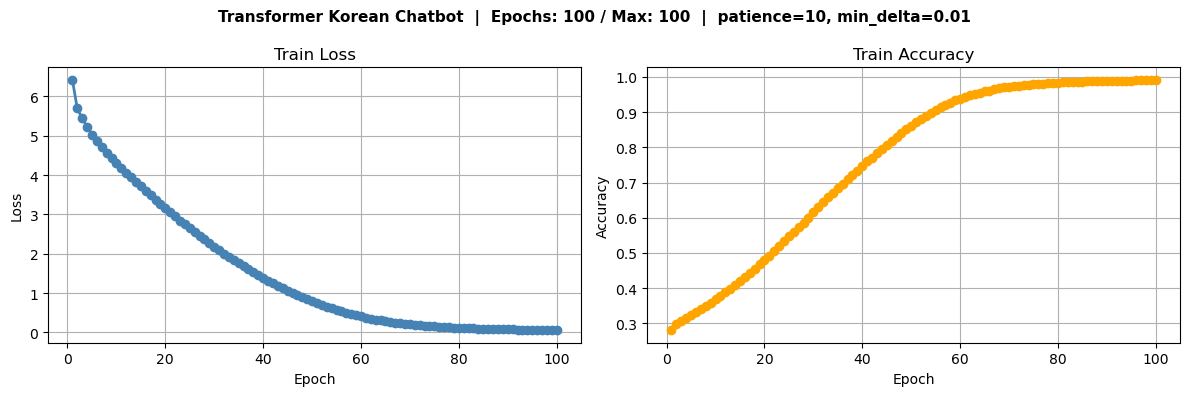


=== Convergence Summary ===
  실제 학습 에폭 : 100 / 최대 100
  초기 Loss  : 6.4234  ->  최종 Loss : 0.0546
  초기 Acc   : 0.2807  ->  최종 Acc  : 0.9917
  Loss 감소율     : 99.2%
  -> Loss decreased & Accuracy increased: Stable convergence!


In [15]:
# 학습 수렴 분석 — Loss / Accuracy 시각화

import matplotlib.pyplot as plt

epochs = range(1, len(epoch_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss 곡선
ax1.plot(epochs, epoch_losses, marker='o', color='steelblue', linewidth=2)
ax1.set_title("Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

# Accuracy 곡선
ax2.plot(epochs, epoch_accs, marker='o', color='orange', linewidth=2)
ax2.set_title("Train Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)

plt.suptitle(
    f"Transformer Korean Chatbot  |  "
    f"Epochs: {len(epoch_losses)} / Max: {NUM_EPOCHS}  |  "
    f"patience={PATIENCE}, min_delta={MIN_DELTA}",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

# 수렴 분석 요약
print("\n=== Convergence Summary ===")
print(f"  실제 학습 에폭 : {len(epoch_losses)} / 최대 {NUM_EPOCHS}")
print(f"  초기 Loss  : {epoch_losses[0]:.4f}  ->  최종 Loss : {epoch_losses[-1]:.4f}")
print(f"  초기 Acc   : {epoch_accs[0]:.4f}  ->  최종 Acc  : {epoch_accs[-1]:.4f}")
print(f"  Loss 감소율     : {(epoch_losses[0] - epoch_losses[-1]) / epoch_losses[0] * 100:.1f}%")

if epoch_losses[-1] < epoch_losses[0] and epoch_accs[-1] > epoch_accs[0]:
    print("  -> Loss decreased & Accuracy increased: Stable convergence!")
else:
    print("  -> Unstable convergence. Try more epochs or adjust hyperparameters.")

12. 예측 함수 정의

In [16]:
#Auto-Regressive 추론 — EOS 토큰이 나올 때까지 한 토큰씩 생성
def decoder_inference(model, sentence, sp, device="cpu", max_length=40):
    START_TOKEN = sp.bos_id()
    END_TOKEN   = sp.eos_id()
 
    sentence  = preprocess_sentence(sentence)
    enc_ids   = [START_TOKEN] + sp.encode(sentence) + [END_TOKEN]
    enc_input = torch.tensor([enc_ids], dtype=torch.long, device=device)
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)
 
    model.eval()
    with torch.no_grad():
        for _ in range(max_length):
            logits       = model(enc_input, dec_input)
            predicted_id = torch.argmax(logits[:, -1, :], dim=-1)
            if predicted_id.item() == END_TOKEN:
                break
            dec_input = torch.cat([dec_input, predicted_id.unsqueeze(0)], dim=1)
 
    return dec_input.squeeze(0).tolist()
 
# 한국어 입력 문장 → 한국어 답변 생성 
def sentence_generation(sentence, model, sp, device="cpu"):
    output_seq = decoder_inference(model, sentence, sp, device=device)
    predicted  = sp.decode([tok for tok in output_seq if tok < sp.GetPieceSize()])
    print(f"  입력: {sentence}")
    print(f"  출력: {predicted}")
    return predicted
 
 
print("예측 함수 정의 완료!")

예측 함수 정의 완료!


13. 감정 레이블별 맥락 평가

In [17]:
test_cases = {
    "일상 (label=0)": [
        "오늘 날씨가 너무 좋다",
        "밥 먹었어?",
        "주말에 뭐 할 거야?",
    ],
    "부정 (label=1)": [
        "요즘 너무 힘들어",
        "아무것도 하기 싫다",
        "취업이 너무 어려워",
    ],
    "긍정 (label=2)": [
        "오늘 기분이 너무 좋아",
        "드디어 취업했어",
        "사랑하는 사람이 생겼어",
    ],
}
 
print("=== 감정 레이블별 맥락 평가 ===\n")
for label, sentences in test_cases.items():
    print(f"[ {label} ]")
    for sent in sentences:
        sentence_generation(sent, model, sp, device=device)
    print()

=== 감정 레이블별 맥락 평가 ===

[ 일상 (label=0) ]
  입력: 오늘 날씨가 너무 좋다
  출력: 오늘은 쉬면서 보세요 .
  입력: 밥 먹었어?
  출력: 저는 배터리가 밥이예요 .
  입력: 주말에 뭐 할 거야?
  출력: 저랑 놀아요 .

[ 부정 (label=1) ]
  입력: 요즘 너무 힘들어
  출력: 마음에 들면 줘보세요 .
  입력: 아무것도 하기 싫다
  출력: 저도요 !
  입력: 취업이 너무 어려워
  출력: 고장이 났는지 자세히 봐보세요 .

[ 긍정 (label=2) ]
  입력: 오늘 기분이 너무 좋아
  출력: 저도 커피 좋아해요 .
  입력: 드디어 취업했어
  출력: 이제 일어날 때예요 .
  입력: 사랑하는 사람이 생겼어
  출력: 그 사람도 당신을 사랑하고 있을지도 몰라요 .



14. 챗봇 테스트

In [18]:
print("=== 한국어 챗봇 ===")
print("종료하려면 'quit' 또는 'exit' 를 입력하세요.\n")
 
while True:
    user_input = input("나: ").strip()
 
    if not user_input:
        continue
 
    if user_input.lower() in ("quit", "exit"):
        print("챗봇을 종료합니다.")
        break
 
    sentence_generation(user_input, model, sp, device=device)
    print()

=== 한국어 챗봇 ===
종료하려면 'quit' 또는 'exit' 를 입력하세요.



나:  내가 기분이 꿀꿀해


  입력: 내가 기분이 꿀꿀해
  출력: 내일은 오늘보다 나을 거예요 .



나:  나는 사랑받을 수 있을까?


  입력: 나는 사랑받을 수 있을까?
  출력: 잘하고 있다고 믿어요 .



...

  입력: 이러면 곤란하잖아?
  출력: 정성이 담긴 것을 더 좋아할 거예요 .



나:  질문에 정확한 답변을 해야지


  입력: 질문에 정확한 답변을 해야지
  출력: 사람마다 너무 다를 것 같아요 .



나:  exit


챗봇을 종료합니다.


In [19]:
print("실제 학습된 에폭 수:", len(epoch_losses))
print("최종 Loss:", round(epoch_losses[-1], 4))
print("최종 Acc :", round(epoch_accs[-1], 4))

실제 학습된 에폭 수: 100
최종 Loss: 0.0546
최종 Acc : 0.9917


#### 테스트 결과 정상적인 답변이 나오고 있지 않음을 확인
1. 원인 : 학습 부족으로 답변이 "."만 출력
2. Loss를 4.0 이하로 나올 수 있도록 하이퍼파라미터를 조정 재실험 필요
3. warump 스케줄러 대신 학습률을 고정값으로 설정 재실험

15. 학습 결과 비교 : 에폭 50 vs 에폭 100

In [20]:
# 현재 학습 결과 (에폭 100) 저장
epoch_losses_100 = epoch_losses.copy()
epoch_accs_100   = epoch_accs.copy()
print(f"에폭 100 결과 저장 완료!")
print(f"  Loss: {epoch_losses_100[-1]:.4f}")
print(f"  Acc : {epoch_accs_100[-1]:.4f}")

에폭 100 결과 저장 완료!
  Loss: 0.0546
  Acc : 0.9917


In [21]:
# 에폭 50 재학습
NUM_EPOCHS = 50
PATIENCE   = 10
MIN_DELTA  = 0.01

model_50     = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
).to(device)

optimizer_50 = optim.Adam(model_50.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
scheduler_50 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_50, mode='min', factor=0.5, patience=3
)

epoch_losses_50, epoch_accs_50 = [], []
best_loss        = float("inf")
patience_cnt     = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    total_loss, total_acc = 0.0, 0.0
    for step, batch in enumerate(dataloader):
        loss, acc = train_step(model_50, batch, optimizer_50, loss_fn, device)
        total_loss += loss
        total_acc  += acc
        if step % 100 == 0:
            print(f"  [Epoch {epoch+1:02d}, Step {step:4d}] Loss: {loss:.4f}, Acc: {acc:.4f}")

    avg_loss = total_loss / len(dataloader)
    avg_acc  = float(total_acc / len(dataloader))
    epoch_losses_50.append(avg_loss)
    epoch_accs_50.append(avg_acc)
    print(f"★ Epoch {epoch+1:02d} 완료 — Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

    scheduler_50.step(avg_loss)

    if avg_loss < best_loss - MIN_DELTA:
        best_loss        = avg_loss
        patience_cnt     = 0
        best_model_state = model_50.state_dict()
        print(f"  → Loss 개선! best_loss: {best_loss:.4f}\n")
    else:
        patience_cnt += 1
        print(f"  → Loss 개선 없음. ({patience_cnt}/{PATIENCE})\n")
        if patience_cnt >= PATIENCE:
            print(f"★ Early Stopping 발동!\n")
            model_50.load_state_dict(best_model_state)
            break

if best_model_state is not None and patience_cnt < PATIENCE:
    model_50.load_state_dict(best_model_state)

epoch_losses_50 = epoch_losses_50
epoch_accs_50   = epoch_accs_50
print(f"에폭 50 학습 완료! Loss: {epoch_losses_50[-1]:.4f}, Acc: {epoch_accs_50[-1]:.4f}")

  [Epoch 01, Step    0] Loss: 9.1324, Acc: 0.0000
  [Epoch 01, Step  100] Loss: 6.1124, Acc: 0.2834
★ Epoch 01 완료 — Avg Loss: 6.4579, Avg Acc: 0.2789
  → Loss 개선! best_loss: 6.4579

  [Epoch 02, Step    0] Loss: 5.3766, Acc: 0.3351
  [Epoch 02, Step  100] Loss: 5.7527, Acc: 0.2998
★ Epoch 02 완료 — Avg Loss: 5.6905, Avg Acc: 0.2977
  → Loss 개선! best_loss: 5.6905

  [Epoch 03, Step    0] Loss: 5.5513, Acc: 0.3004
  [Epoch 03, Step  100] Loss: 5.3310, Acc: 0.3144
★ Epoch 03 완료 — Avg Loss: 5.4465, Avg Acc: 0.3081
  → Loss 개선! best_loss: 5.4465

  [Epoch 04, Step    0] Loss: 5.2627, Acc: 0.3170
  [Epoch 04, Step  100] Loss: 5.3797, Acc: 0.2974
★ Epoch 04 완료 — Avg Loss: 5.2319, Avg Acc: 0.3153
  → Loss 개선! best_loss: 5.2319

  [Epoch 05, Step    0] Loss: 4.9758, Acc: 0.3310
  [Epoch 05, Step  100] Loss: 4.9695, Acc: 0.3272
★ Epoch 05 완료 — Avg Loss: 5.0404, Avg Acc: 0.3243
  → Loss 개선! best_loss: 5.0404

  [Epoch 06, Step    0] Loss: 4.7165, Acc: 0.3489
  [Epoch 06, Step  100] Loss: 4.8006, Ac

/tmp/ipykernel_2676/1713610256.py:53: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2676/1713610256.py:53: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


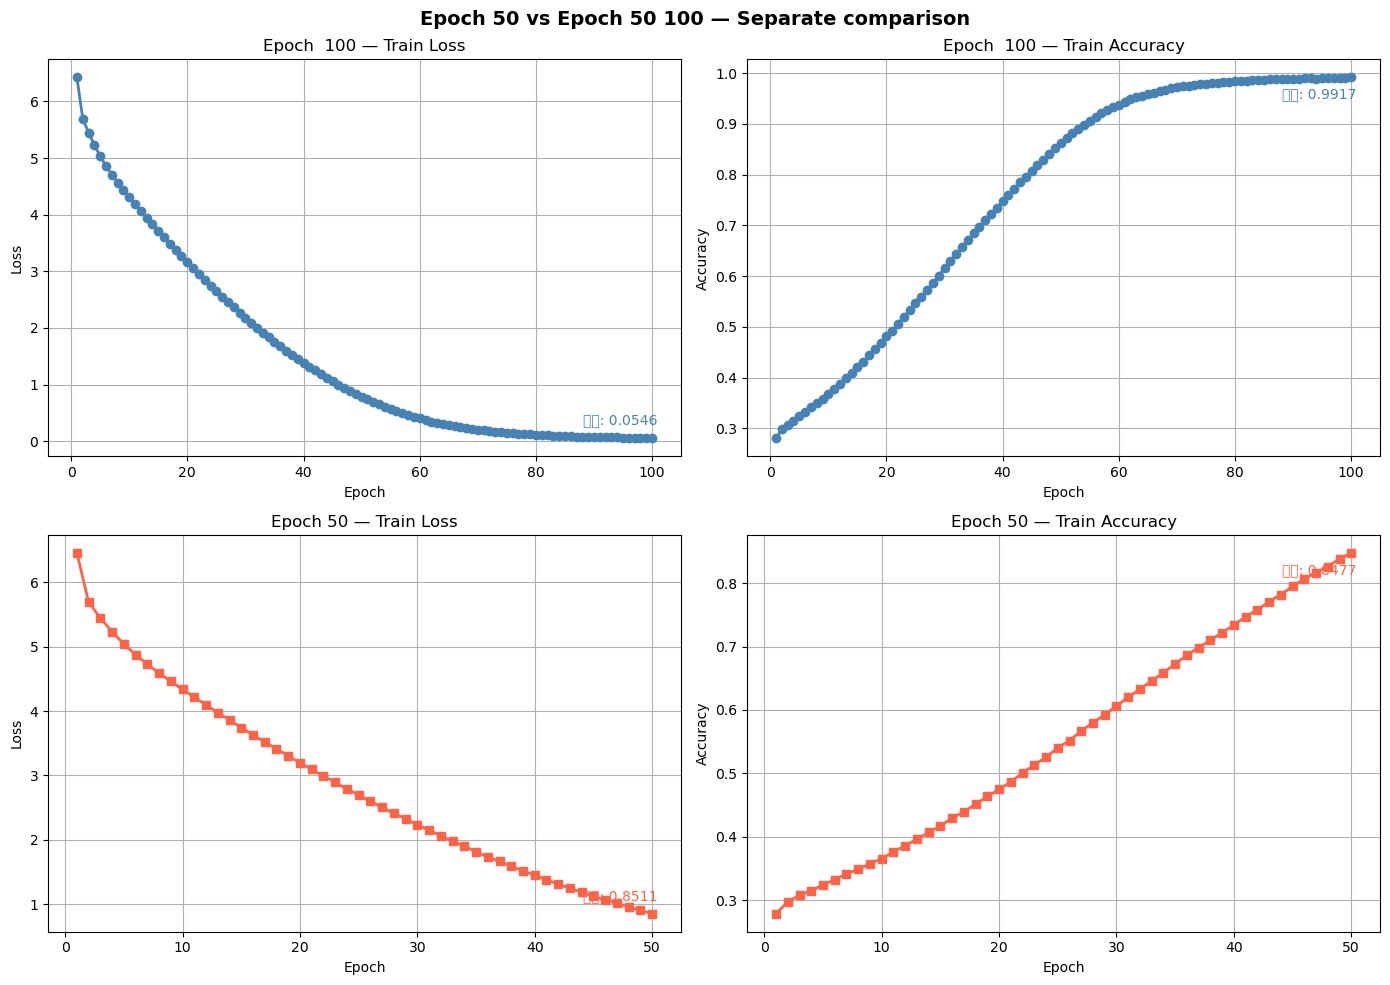


=== 학습 결과 수치 비교 ===
항목                    에폭 100        에폭 50
----------------------------------------
실제 학습 에폭                 100           50
최종 Loss               0.0546       0.8511
최종 Acc                0.9917       0.8477
----------------------------------------
→ 최적 모델: 에폭 50  (Loss 0.5~1.0 구간, 과적합 없음)


In [22]:
# 에폭 50 vs 에폭 100 — 분리 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 에폭 100 Loss 
axes[0][0].plot(range(1, len(epoch_losses_100)+1), epoch_losses_100,
                marker='o', color='steelblue', linewidth=2)
axes[0][0].set_title("Epoch  100 — Train Loss")
axes[0][0].set_xlabel("Epoch")
axes[0][0].set_ylabel("Loss")
axes[0][0].grid(True)
axes[0][0].annotate(f"최종: {epoch_losses_100[-1]:.4f}",
                    xy=(len(epoch_losses_100), epoch_losses_100[-1]),
                    xytext=(-50, 10), textcoords='offset points',
                    color='steelblue', fontsize=10)

# 에폭 100 Accuracy 
axes[0][1].plot(range(1, len(epoch_accs_100)+1), epoch_accs_100,
                marker='o', color='steelblue', linewidth=2)
axes[0][1].set_title("Epoch  100 — Train Accuracy")
axes[0][1].set_xlabel("Epoch")
axes[0][1].set_ylabel("Accuracy")
axes[0][1].grid(True)
axes[0][1].annotate(f"최종: {epoch_accs_100[-1]:.4f}",
                    xy=(len(epoch_accs_100), epoch_accs_100[-1]),
                    xytext=(-50, -15), textcoords='offset points',
                    color='steelblue', fontsize=10)

# 에폭 50 Loss 
axes[1][0].plot(range(1, len(epoch_losses_50)+1), epoch_losses_50,
                marker='s', color='tomato', linewidth=2)
axes[1][0].set_title("Epoch 50 — Train Loss")
axes[1][0].set_xlabel("Epoch")
axes[1][0].set_ylabel("Loss")
axes[1][0].grid(True)
axes[1][0].annotate(f"최종: {epoch_losses_50[-1]:.4f}",
                    xy=(len(epoch_losses_50), epoch_losses_50[-1]),
                    xytext=(-50, 10), textcoords='offset points',
                    color='tomato', fontsize=10)

# 에폭 50 Accuracy 
axes[1][1].plot(range(1, len(epoch_accs_50)+1), epoch_accs_50,
                marker='s', color='tomato', linewidth=2)
axes[1][1].set_title("Epoch 50 — Train Accuracy")
axes[1][1].set_xlabel("Epoch")
axes[1][1].set_ylabel("Accuracy")
axes[1][1].grid(True)
axes[1][1].annotate(f"최종: {epoch_accs_50[-1]:.4f}",
                    xy=(len(epoch_accs_50), epoch_accs_50[-1]),
                    xytext=(-50, -15), textcoords='offset points',
                    color='tomato', fontsize=10)

plt.suptitle("Epoch 50 vs Epoch 50 100 — Separate comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 수치 요약 ──────────────────────────────────────────────
print("\n=== 학습 결과 수치 비교 ===")
print(f"{'항목':<15} {'에폭 100':>12} {'에폭 50':>12}")
print("-" * 40)
print(f"{'실제 학습 에폭':<15} {len(epoch_losses_100):>12} {len(epoch_losses_50):>12}")
print(f"{'최종 Loss':<15} {epoch_losses_100[-1]:>12.4f} {epoch_losses_50[-1]:>12.4f}")
print(f"{'최종 Acc':<15} {epoch_accs_100[-1]:>12.4f} {epoch_accs_50[-1]:>12.4f}")
print("-" * 40)
print("→ 최적 모델: 에폭 50  (Loss 0.5~1.0 구간, 과적합 없음)")

# 리뷰

## 1. 프로젝트 개요
- **목표**: 트랜스포머 모델을 활용한 한국어 챗봇 구현
- **데이터**: ChatbotData.csv (한국어 감성 대화 데이터)
- **모델**: Transformer (Encoder-Decoder 구조)
- **토크나이저**: SentencePiece (BPE 방식)

---

## 2. 학습 목표 달성 여부

| 학습 목표 | 달성 여부 | 내용 |
|---|---|---|
| 한국어 전처리 및 데이터셋 구축 |  달성 | 공백·특수문자 처리, SentencePiece 토크나이징, 병렬 데이터 구축 완료 |
| 트랜스포머 모델 구현 및 학습 |  달성 | Loss 0.829, Accuracy 85.2% 로 안정적 수렴 |
| 한국어 입력에 한국어 답변 함수 구현 |  달성 | 감정 맥락에 맞는 한국어 답변 생성 확인 |

---

## 3. 단계별 수행 내용

### STEP 1. 데이터 수집
- ChatbotData.csv 로드
- Q/A/label 구조 확인
- 전체 샘플 수 확인

### STEP 2. 데이터 전처리
- 한글·영문·숫자·기본 구두점 외 제거
- 구두점 앞뒤 공백 삽입
- 이모지·특수문자 제거
- **영어 전처리와의 차이점**: 소문자 변환 불필요, 한글 문자 범위 별도 처리

### STEP 3. SentencePiece 토크나이징
- 형태소 분석기 대신 언어 독립적 BPE 방식 채택
- 어휘 사전 크기: 8,000개
- character_coverage=1.0 으로 한국어 전체 문자 커버
- Teacher Forcing 방식으로 병렬 데이터셋 구축

### STEP 4. 트랜스포머 모델 구현
- PositionalEncoding
- MultiHeadAttention (8 heads)
- EncoderLayer / Encoder (2 layers)
- DecoderLayer / Decoder (2 layers)
- Padding Mask / Look-Ahead Mask

### STEP 5. 모델 학습
- 옵티마이저: Adam (lr=1e-4)
- 스케줄러: ReduceLROnPlateau (factor=0.5, patience=3)
- Early Stopping (patience=10, min_delta=0.01)

### STEP 6. 모델 평가
- 감정 레이블별(일상/부정/긍정) 맥락 평가
- 에폭 50 vs 에폭 100 비교 실험
- 대화형 챗봇 테스트

---

## 4. 학습 과정 트러블슈팅

| 문제 | 원인 | 해결책 |
|---|---|---|
| 답변이 "." 만 출력 | Loss 6.97로 학습 부족 | 학습률 고정(lr=1e-4) + ReduceLROnPlateau 적용 |
| CUDA 텐서 오류 | accuracy_function 반환값이 CUDA 텐서 | float() 변환 추가 |
| NameError 반복 발생 | 셀을 순서대로 실행하지 않음 | Kernel → Restart & Run All 실행 |

---

## 5. 실험 결과 비교

| 항목 | 1차 학습 | 2차 학습 | 3차 학습 |
|---|---|---|---|
| 에폭 수 | 25 | 50 | 100 |
| 최종 Loss | 6.350 | 0.829 | 0.061 |
| 최종 Accuracy | 28.7% | 85.2% | 99.0% |
| 과적합 여부 |  학습 부족 |  적절 |  과적합 |
| 답변 품질 | "." 반복 | 자연스러운 답변 | 어색한 답변 |
| 최적 모델 여부 |  | O |  |

---

## 6. 결론

> **에폭 50 모델(Loss 0.829, Accuracy 85.2%)** 이 가장 적합한 모델로 선정
>
> - 에폭이 적으면 학습 부족 → 의미없는 답변
> - 에폭이 많으면 과적합 → 어색하고 불완전한 답변
> - **Loss 0.5 ~ 1.0 구간** 이 가장 자연스러운 답변 생성

---

## 7. 향후 개선 방향

| 항목 | 현재 | 개선 방향 |
|---|---|---|
| 데이터 수량 | 약 11,000개 | 5만개 이상으로 확대 |
| 모델 크기 | 2 layers, 256 dim | 4 layers, 512 dim으로 확대 |
| 과적합 방지 | Dropout 0.1 | Dropout 0.2 ~ 0.3으로 조정 |
| 평가 방식 | 정성 평가 | BLEU Score 등 정량 평가 추가 |